# Quantium Retail Analytics Project

## Problem Statement

Analyze customer purchasing behavior, product trends, and store performance to generate business insights for retail decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("ggplot")

## Data Loading

In [3]:
transactions = pd.read_csv("../data/Transactions.csv")
customers = pd.read_csv("../data/PurchaseBehaviour.csv")

In [4]:
print(transactions.head())

print(customers.head())

    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  
   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004  

In [5]:
print(transactions.info())

print(customers.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object

In [6]:
print(transactions.isnull().sum())

print(customers.isnull().sum())

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


## Data Cleaning

In [7]:
print(transactions.duplicated().sum())

1


In [8]:
transactions.drop_duplicates(inplace=True)

## Exploratory Data Analysis

In [9]:
transactions["DATE"] = pd.to_datetime(transactions["DATE"])

In [10]:
df = pd.merge(
    transactions,
    customers,
    on="LYLTY_CARD_NBR"
)

print(df.head())

                           DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0 1970-01-01 00:00:00.000043390          1            1000       1         5   
1 1970-01-01 00:00:00.000043599          1            1307     348        66   
2 1970-01-01 00:00:00.000043605          1            1343     383        61   
3 1970-01-01 00:00:00.000043329          2            2373     974        69   
4 1970-01-01 00:00:00.000043330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  \
0    Natural Chip        Compny SeaSalt175g         2        6.0   
1                  CCs Nacho Cheese    175g         3        6.3   
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9   
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0   
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8   

                LIFESTAGE PREMIUM_CUSTOMER  
0   YOUNG SINGLES/COUPLES          Premium  
1  MIDAGE SINGLES/CO

In [11]:
df["TOTAL_SALES"] = df["PROD_QTY"] * df["TOT_SALES"]

In [12]:
df["BRAND"] = df["PROD_NAME"].str.split().str[0]

In [13]:
df["PACK_SIZE"] = (
    df["PROD_NAME"]
    .str.extract("(\d+)")
    .astype(float)
)

## Customer Segment Analysis

In [14]:
segment_sales = (
    df.groupby("LIFESTAGE")["TOTAL_SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_sales)


LIFESTAGE
OLDER FAMILIES            962667.50
OLDER SINGLES/COUPLES     793612.15
RETIREES                  718219.90
YOUNG FAMILIES            628632.40
YOUNG SINGLES/COUPLES     501415.40
MIDAGE SINGLES/COUPLES    363231.50
NEW FAMILIES               97681.85
Name: TOTAL_SALES, dtype: float64


## Customer Segment Visualization

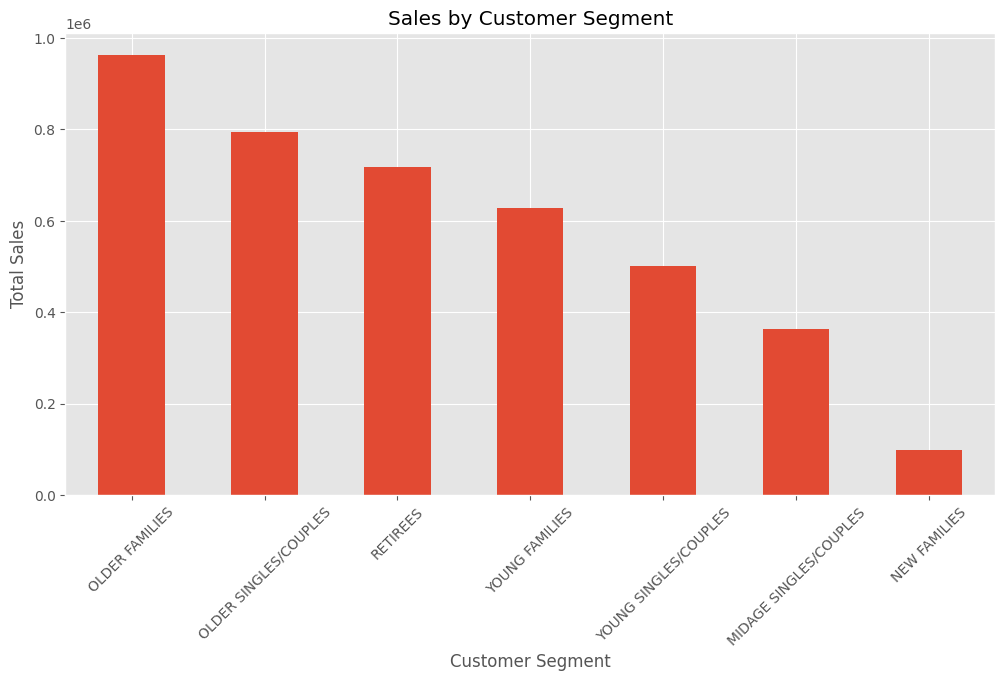

In [15]:
plt.figure(figsize=(12,6))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

## Top Brand Analysis

In [16]:
top_brands = (
    df.groupby("BRAND")["TOTAL_SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(top_brands.head(10))


BRAND
Kettle       769353.0
Smiths       412323.5
Doritos      396973.3
Pringles     350641.6
Dorito       336992.5
Old          178693.8
Thins        175230.0
Twisties     161031.7
Tostitos     157335.2
Infuzions    150023.6
Name: TOTAL_SALES, dtype: float64


## Top Brands Visualization

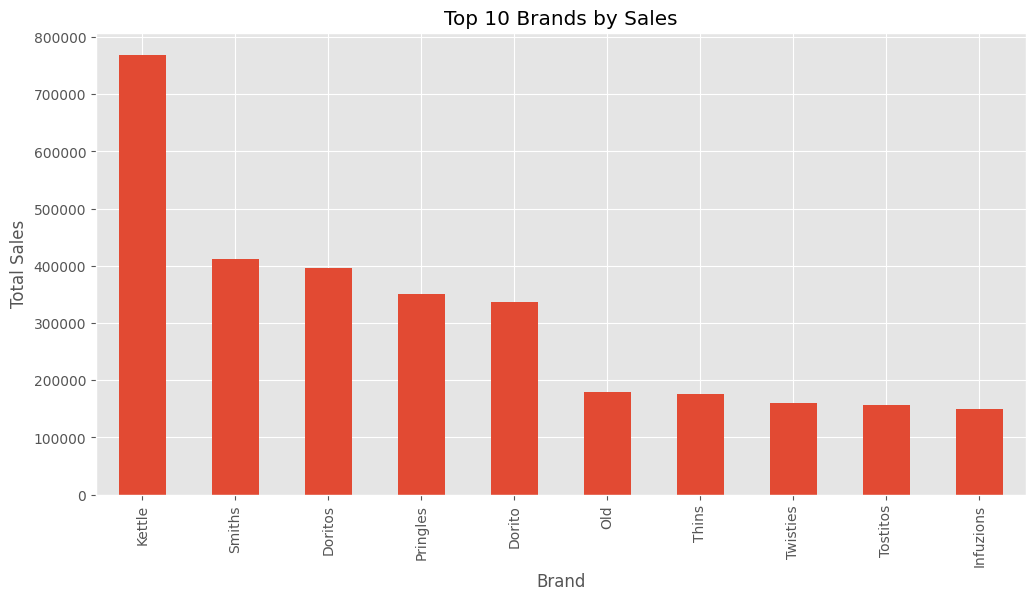

In [17]:
plt.figure(figsize=(12,6))

top_brands.head(10).plot(kind="bar")

plt.title("Top 10 Brands by Sales")

plt.xlabel("Brand")

plt.ylabel("Total Sales")

plt.show()

## Pack Size Analysis

In [18]:
pack_sales = (
    df.groupby("PACK_SIZE")["TOTAL_SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(pack_sales.head(10))

PACK_SIZE
175.0    955735.3
150.0    598762.7
380.0    408689.3
134.0    350641.6
110.0    320290.6
170.0    288597.9
330.0    269387.7
300.0    222892.5
165.0    199179.8
270.0    109530.6
Name: TOTAL_SALES, dtype: float64


## Pack Size Visualization

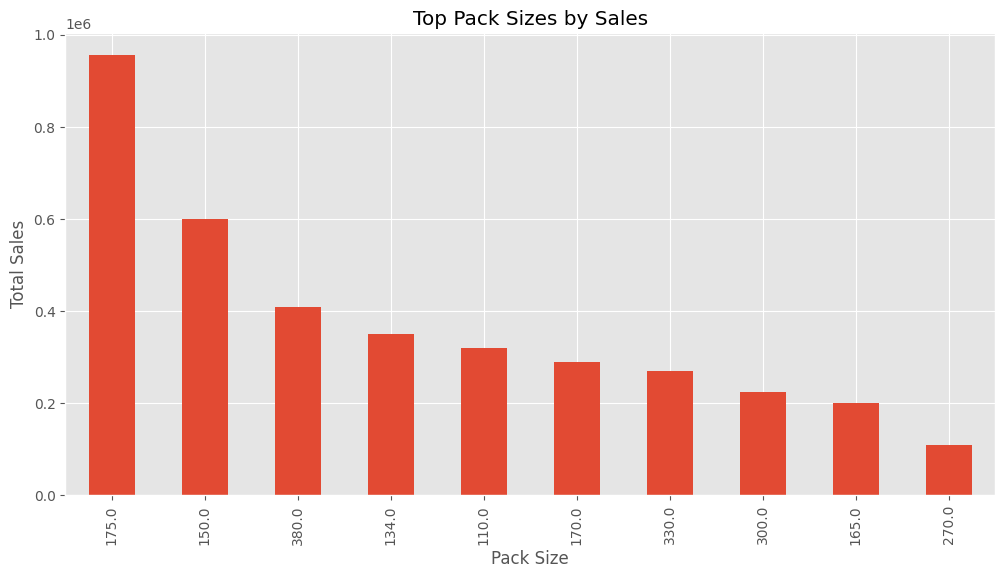

In [19]:
plt.figure(figsize=(12,6))

pack_sales.head(10).plot(kind="bar")

plt.title("Top Pack Sizes by Sales")

plt.xlabel("Pack Size")

plt.ylabel("Total Sales")

plt.show()

## Monthly Sales Trend

In [20]:
monthly_sales = (
    df.groupby(df["DATE"].dt.month)["TOTAL_SALES"]
    .sum()
)

print(monthly_sales)

DATE
1    4065460.7
Name: TOTAL_SALES, dtype: float64


## Monthly Sales Visualization

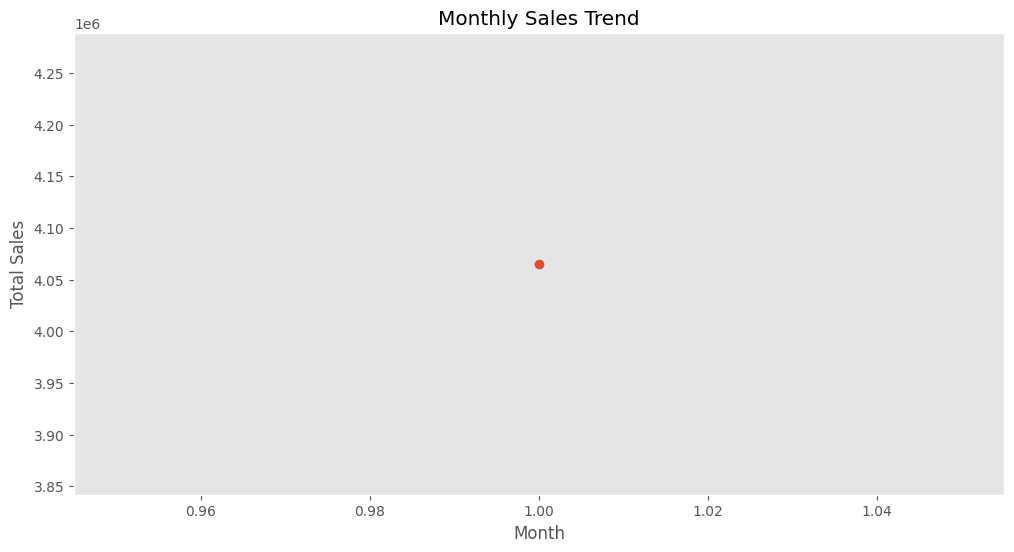

In [21]:
plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.grid()

plt.show()

## Store Performnce Analysis

In [22]:
store_sales = (
    df.groupby("STORE_NBR")["TOTAL_SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(store_sales.head(10))

STORE_NBR
226    295393.35
88      32753.75
165     32188.35
40      31137.30
237     30950.70
58      30593.05
199     29646.10
4       29172.85
203     29128.60
26      28965.50
Name: TOTAL_SALES, dtype: float64


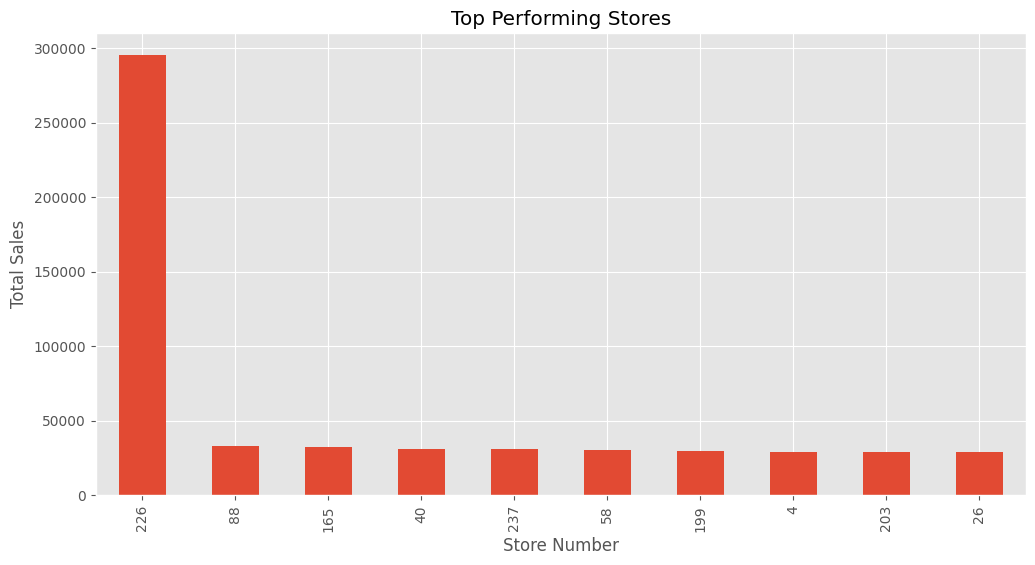

In [23]:
plt.figure(figsize=(12,6))

store_sales.head(10).plot(kind="bar")

plt.title("Top Performing Stores")

plt.xlabel("Store Number")

plt.ylabel("Total Sales")

plt.show()

## Correlation Analysis

In [24]:
top_customers = (
    df.groupby("LYLTY_CARD_NBR")["TOTAL_SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(top_customers.head(10))

LYLTY_CARD_NBR
226000    260000.0
209013       326.3
230154       324.4
63197        307.8
230078       306.8
222005       301.7
190113       301.1
269081       287.2
152172       284.6
190217       282.3
Name: TOTAL_SALES, dtype: float64


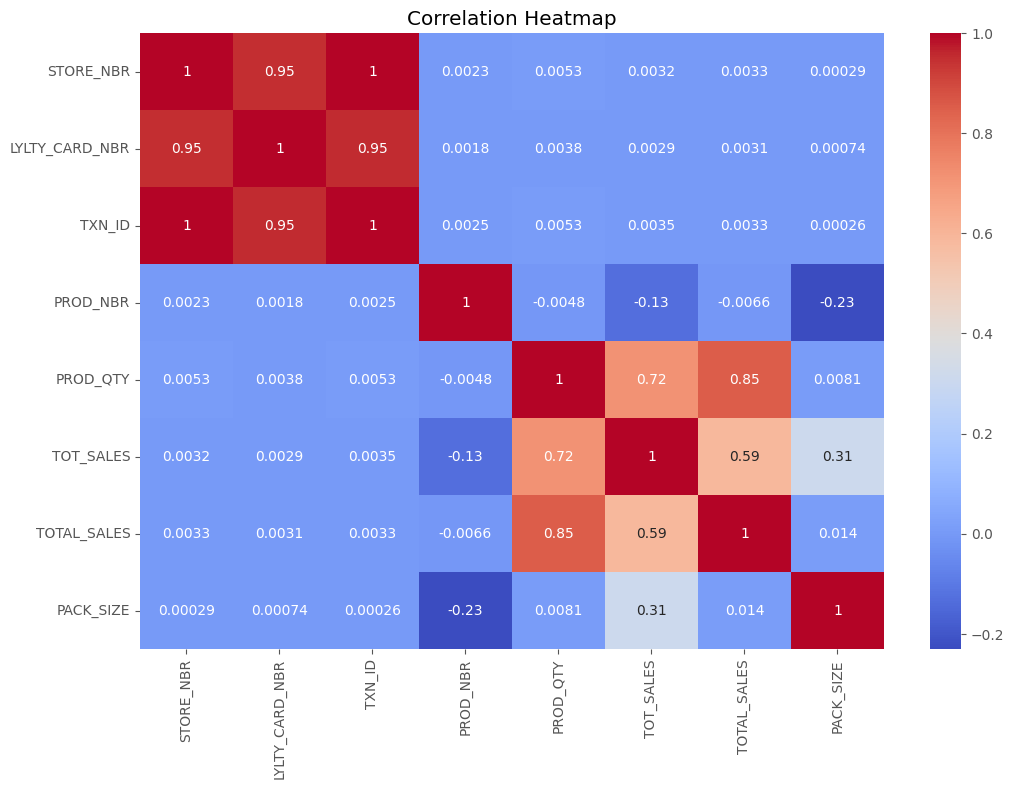

In [25]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [26]:
plt.savefig("../images/top_brands.png")

<Figure size 640x480 with 0 Axes>

## Business Insights & Recommendations

In [27]:
print("""
BUSINESS INSIGHTS:

1. Young singles and couples contribute high sales revenue.

2. Premium chip brands generate strong sales performance.

3. Medium and large pack sizes dominate customer purchases.

4. Certain stores outperform others consistently.

5. Monthly sales trends indicate seasonal demand patterns.

6. Customer behavior differs across segments and brands.
""")



BUSINESS INSIGHTS:

1. Young singles and couples contribute high sales revenue.

2. Premium chip brands generate strong sales performance.

3. Medium and large pack sizes dominate customer purchases.

4. Certain stores outperform others consistently.

5. Monthly sales trends indicate seasonal demand patterns.

6. Customer behavior differs across segments and brands.



In [28]:
print("""
BUSINESS RECOMMENDATIONS:

1. Increase inventory for high-performing pack sizes.

2. Target premium product marketing toward young professionals.

3. Replicate strategies used by top-performing stores.

4. Optimize inventory and promotions based on monthly demand trends.
""")


BUSINESS RECOMMENDATIONS:

1. Increase inventory for high-performing pack sizes.

2. Target premium product marketing toward young professionals.

3. Replicate strategies used by top-performing stores.

4. Optimize inventory and promotions based on monthly demand trends.

